In [123]:
import numpy as np
import pandas as pd
from matplotlib.lines import lineStyles
from plotly.io import show
from matplotlib import pyplot as plt
import seaborn as sns
from tabulate import tabulate
import vectorbt as vbt
import math

import optuna
from optuna.samplers import RandomSampler, TPESampler

from utils.KrakenHistoricalData import KrakenHistoricalData
from ggTrader.Utils import *

In [124]:
top_kraken = [
    "BTC",  # 1 Bitcoin
    "ETH",  # 2 Ethereum
    "XRP",  # 3 XRP
    # "BNB",  # 4 BNB
    "SOL",  # 5 Solana
    "TRX",  # 6 TRON
    "DOGE",  # 7 Dogecoin
    "ADA",  # 8 Cardano
    # "HYPE",  # 9 Hyperliquid
    "LINK",  # 10 Chainlink
    "BCH",  # 11 Bitcoin Cash
    "XLM",  # 12 Stellar
    "SUI",  # 13 Sui
    # "HBAR",  # 14 Hedera
    "AVAX",  # 15 Avalanche
    "ZEC",  # 16 Zcash
    "LTC",  # 17 Litecoin
    "XMR",  # 18 Monero
    "SHIB",  # 19 Shiba Inu
    # "TON",  # 20 Toncoin
    # "CRO",  # 21 Crypto.com
    "DOT",  # 22 Polkadot
    # "MNT",  # 23 Mantle
    # "TAO",  # 24 Bittensor
    "UNI",  # 25 Uniswap
]

Setup

In [125]:
# setup
k = KrakenHistoricalData()

start_equity = 1000
symbols = ["BTC", "ETH", "XRP"]
symbols = top_kraken[:5]
interval = "4h"
n_trials = 200
min_trades = 10
low_trades = False
max_lookback = int(6*3)  # i want to look back no further than 3 days
sampler = RandomSampler(seed=42)  # optional seed for reproducibility
# sampler = TPESampler(seed=42)

# Time Range
end = pd.to_datetime("2025-09-30").tz_localize('UTC')
# start = end - pd.Timedelta(days=30 * 6)
start = pd.to_datetime("2023-01-01").tz_localize('UTC')

# Indicator Params
params_default = {'sar_acceleration': 0.03,
                  'sar_maximum': 0.3,
                  'atr_multiplier': 3,
                  'adx_threshold': 25,
                  'adx_length': 14,
                  'atr_length': 14,
                  'use_high': False,
                  'use_dmp_cross': False,
                  }
params = params_default.copy()
# Fees
maker_fee = 0.0025
taker_fee = 0.004
transaction_fee = (maker_fee + taker_fee) / 2

data_df = k.get_ohlcv_df(symbols, interval=interval, start=start, end=end)

close = data_df.xs('close', axis=1, level=1)
high = data_df.xs('high', axis=1, level=1)
low = data_df.xs('low', axis=1, level=1)
open = data_df.xs('open', axis=1, level=1)


## Part 1: Initial Parameter Search

In [126]:
def objective(trial: optuna.Trial):
    # Entry
    params['adx_threshold'] = trial.suggest_int("adx_threshold", 0, 80, step=2)  #
    params['adx_length'] = trial.suggest_int("adx_length", 2, max_lookback, step=2)
    params['sar_acceleration'] = trial.suggest_float("sar_acceleration", 0.01, 0.05, step=0.01) # default .02
    params['sar_maximum'] = trial.suggest_float("sar_maximum", 0.1, 0.5, step=0.01)  # default .2
    params['use_dmp_cross'] = trial.suggest_categorical("use_dmp_cross", [True, False])

    # Exit
    params['atr_multiplier'] = trial.suggest_float("atr_multiplier", 1, 15, step=0.5)
    params['atr_length'] = trial.suggest_int("atr_length", 10, max_lookback, step=2)
    params['use_high'] = trial.suggest_categorical("use_high", [True, False])

    entries, exits, sl_stop = calc_signals(close, high, low, **params)

    pf = vbt.Portfolio.from_signals(close,
                                    entries=entries,
                                    exits=exits,
                                    size=1,
                                    size_type='percent',
                                    direction='longonly',
                                    sl_stop=sl_stop,
                                    sl_trail=True,
                                    freq=interval,
                                    fees=transaction_fee,
                                    init_cash=start_equity,
                                    )
    stats_df = pd.DataFrame({col: pf[col].stats() for col in pf.wrapper.columns})
    sharpe = stats_df.loc["Sharpe Ratio"].mean()
    low_trades = stats_df.loc["Total Trades"].min() < min_trades
    if sharpe is None or math.isnan(sharpe) or math.isinf(sharpe):
        raise optuna.exceptions.TrialPruned("Invalid objective (NaN/Inf).")
    elif low_trades:
        raise optuna.exceptions.TrialPruned("Invalid objective (low trades).")
    wide = stats_df_to_wide(stats_df, trial.number)
    params_df = pd.DataFrame(params, index=wide.index)
    trial_summary = pd.concat([wide, params_df], axis=1)
    trials_summary_list.append(trial_summary)

    return sharpe


trials_summary_list = []

study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=n_trials)
trials_summary = pd.concat(trials_summary_list, axis=0).reset_index(drop=True)

[I 2025-11-10 11:52:09,709] A new study created in memory with name: no-name-77809e7b-8be9-44fc-adbd-79281ebb50d3
[I 2025-11-10 11:52:10,374] Trial 0 finished with value: 0.3638802393472435 and parameters: {'adx_threshold': 30, 'adx_length': 18, 'sar_acceleration': 0.04, 'sar_maximum': 0.33999999999999997, 'use_dmp_cross': True, 'atr_multiplier': 1.5, 'atr_length': 18, 'use_high': False}. Best is trial 0 with value: 0.3638802393472435.
[I 2025-11-10 11:52:11,498] Trial 1 finished with value: 1.1111835422802154 and parameters: {'adx_threshold': 0, 'adx_length': 18, 'sar_acceleration': 0.05, 'sar_maximum': 0.18, 'use_dmp_cross': False, 'atr_multiplier': 5.0, 'atr_length': 14, 'use_high': True}. Best is trial 1 with value: 1.1111835422802154.
[I 2025-11-10 11:52:12,131] Trial 2 pruned. Invalid objective (low trades).
[I 2025-11-10 11:52:12,830] Trial 3 pruned. Invalid objective (low trades).
[I 2025-11-10 11:52:13,538] Trial 4 finished with value: 1.1845733834576666 and parameters: {'adx_

Study Results

In [127]:
trials = study.trials_dataframe()
trials.sort_values('value', inplace=True, ascending=False)
trials.columns = trials.columns.str.removeprefix('params_')
trials.drop(['datetime_start', 'datetime_complete', 'duration', 'state'], axis=1, inplace=True)
print(tabulate(trials, headers='keys', tablefmt='github', showindex=False))



|   number |      value |   adx_length |   adx_threshold |   atr_length |   atr_multiplier |   sar_acceleration |   sar_maximum | use_dmp_cross   | use_high   |
|----------|------------|--------------|-----------------|--------------|------------------|--------------------|---------------|-----------------|------------|
|       40 |   1.32036  |           18 |               8 |           10 |              6.5 |               0.03 |          0.43 | False           | True       |
|       73 |   1.31415  |           16 |              12 |           18 |              6.5 |               0.04 |          0.31 | False           | True       |
|      194 |   1.29458  |            8 |               4 |           10 |              7   |               0.04 |          0.39 | True            | False      |
|      103 |   1.25127  |           12 |               2 |           16 |              5.5 |               0.02 |          0.14 | False           | False      |
|      126 |   1.23976  |         

In [128]:
parameters = list(params.keys())
performance = ['Sharpe Ratio', 'Sortino Ratio', 'Calmar Ratio', 'Profit Factor', 'Total Return [%]', 'Total Trades']

#convert bool to 0s and 1s
trials_summary['use_high'] = trials_summary['use_high'].astype(int)
trials_summary['use_dmp_cross'] = trials_summary['use_dmp_cross'].astype(int)
top_10_pct = int(n_trials * 0.1)
print(f"\nTop 10% Trials Summary ({top_10_pct } Trials):")
cols = parameters + performance

top_runs = trials_summary.sort_values('Sharpe Ratio', ascending=False).groupby('symbol').head(top_10_pct)
print(f"\nPer symbol Average values:")
print(top_runs.groupby('symbol')[cols].mean())
print(f"\nAcross all symbols:")
print(top_runs[cols].describe())


Top 10% Trials Summary (20 Trials):

Per symbol Average values:
        sar_acceleration  sar_maximum  atr_multiplier  adx_threshold  \
symbol                                                                 
BTC               0.0310       0.3190           4.825           21.9   
ETH               0.0310       0.3090           4.500           33.7   
SOL               0.0340       0.3270           5.675           17.5   
TRX               0.0315       0.3210           5.925           13.2   
XRP               0.0340       0.2755           4.525           27.0   

        adx_length  atr_length  use_high  use_dmp_cross  Sharpe Ratio  \
symbol                                                                  
BTC           13.5        13.6      0.60           0.25      1.520723   
ETH           12.8        13.3      0.45           0.65      1.044048   
SOL           13.2        13.6      0.50           0.50      1.423446   
TRX           13.4        13.0      0.60           0.45      1.34

Update defaults for:
- adx_threshold = 20 --> (8 -- 40)
- adx_length = 10 --> default 14 looks okay
- atr_length = 10 --> default 14 looks okay
- atr_multiplier = 3 --> (4 -- 6.5)
- sar_acceleration = 0.02 --> 0.03
- sar_maximum = 0.2 --> 0.3
- use_dmp_cross = True  --> False

In [129]:
best_params = study.best_params
best_value = study.best_value
print(f"\nBest --> Sharpe: {best_value:.2f} ")
print(tabulate(best_params.items(), tablefmt="github"))


Best --> Sharpe: 1.32 
|------------------|-------|
| adx_threshold    |  8    |
| adx_length       | 18    |
| sar_acceleration |  0.03 |
| sar_maximum      |  0.43 |
| use_dmp_cross    |  0    |
| atr_multiplier   |  6.5  |
| atr_length       | 10    |
| use_high         |  1    |


Visualization

In [130]:
fig = optuna.visualization.plot_param_importances(study)
show(fig)

# fig2 = optuna.visualization.plot_slice(study, params=best_params.keys())
# show(fig2)


From the slice plot can notice a few things...

- ATR multiplier <2 also looks ideal as under 2 sortino values reach > 6



In [131]:
fig3 = optuna.visualization.plot_optimization_history(study)
show(fig3)

Seaborn plots

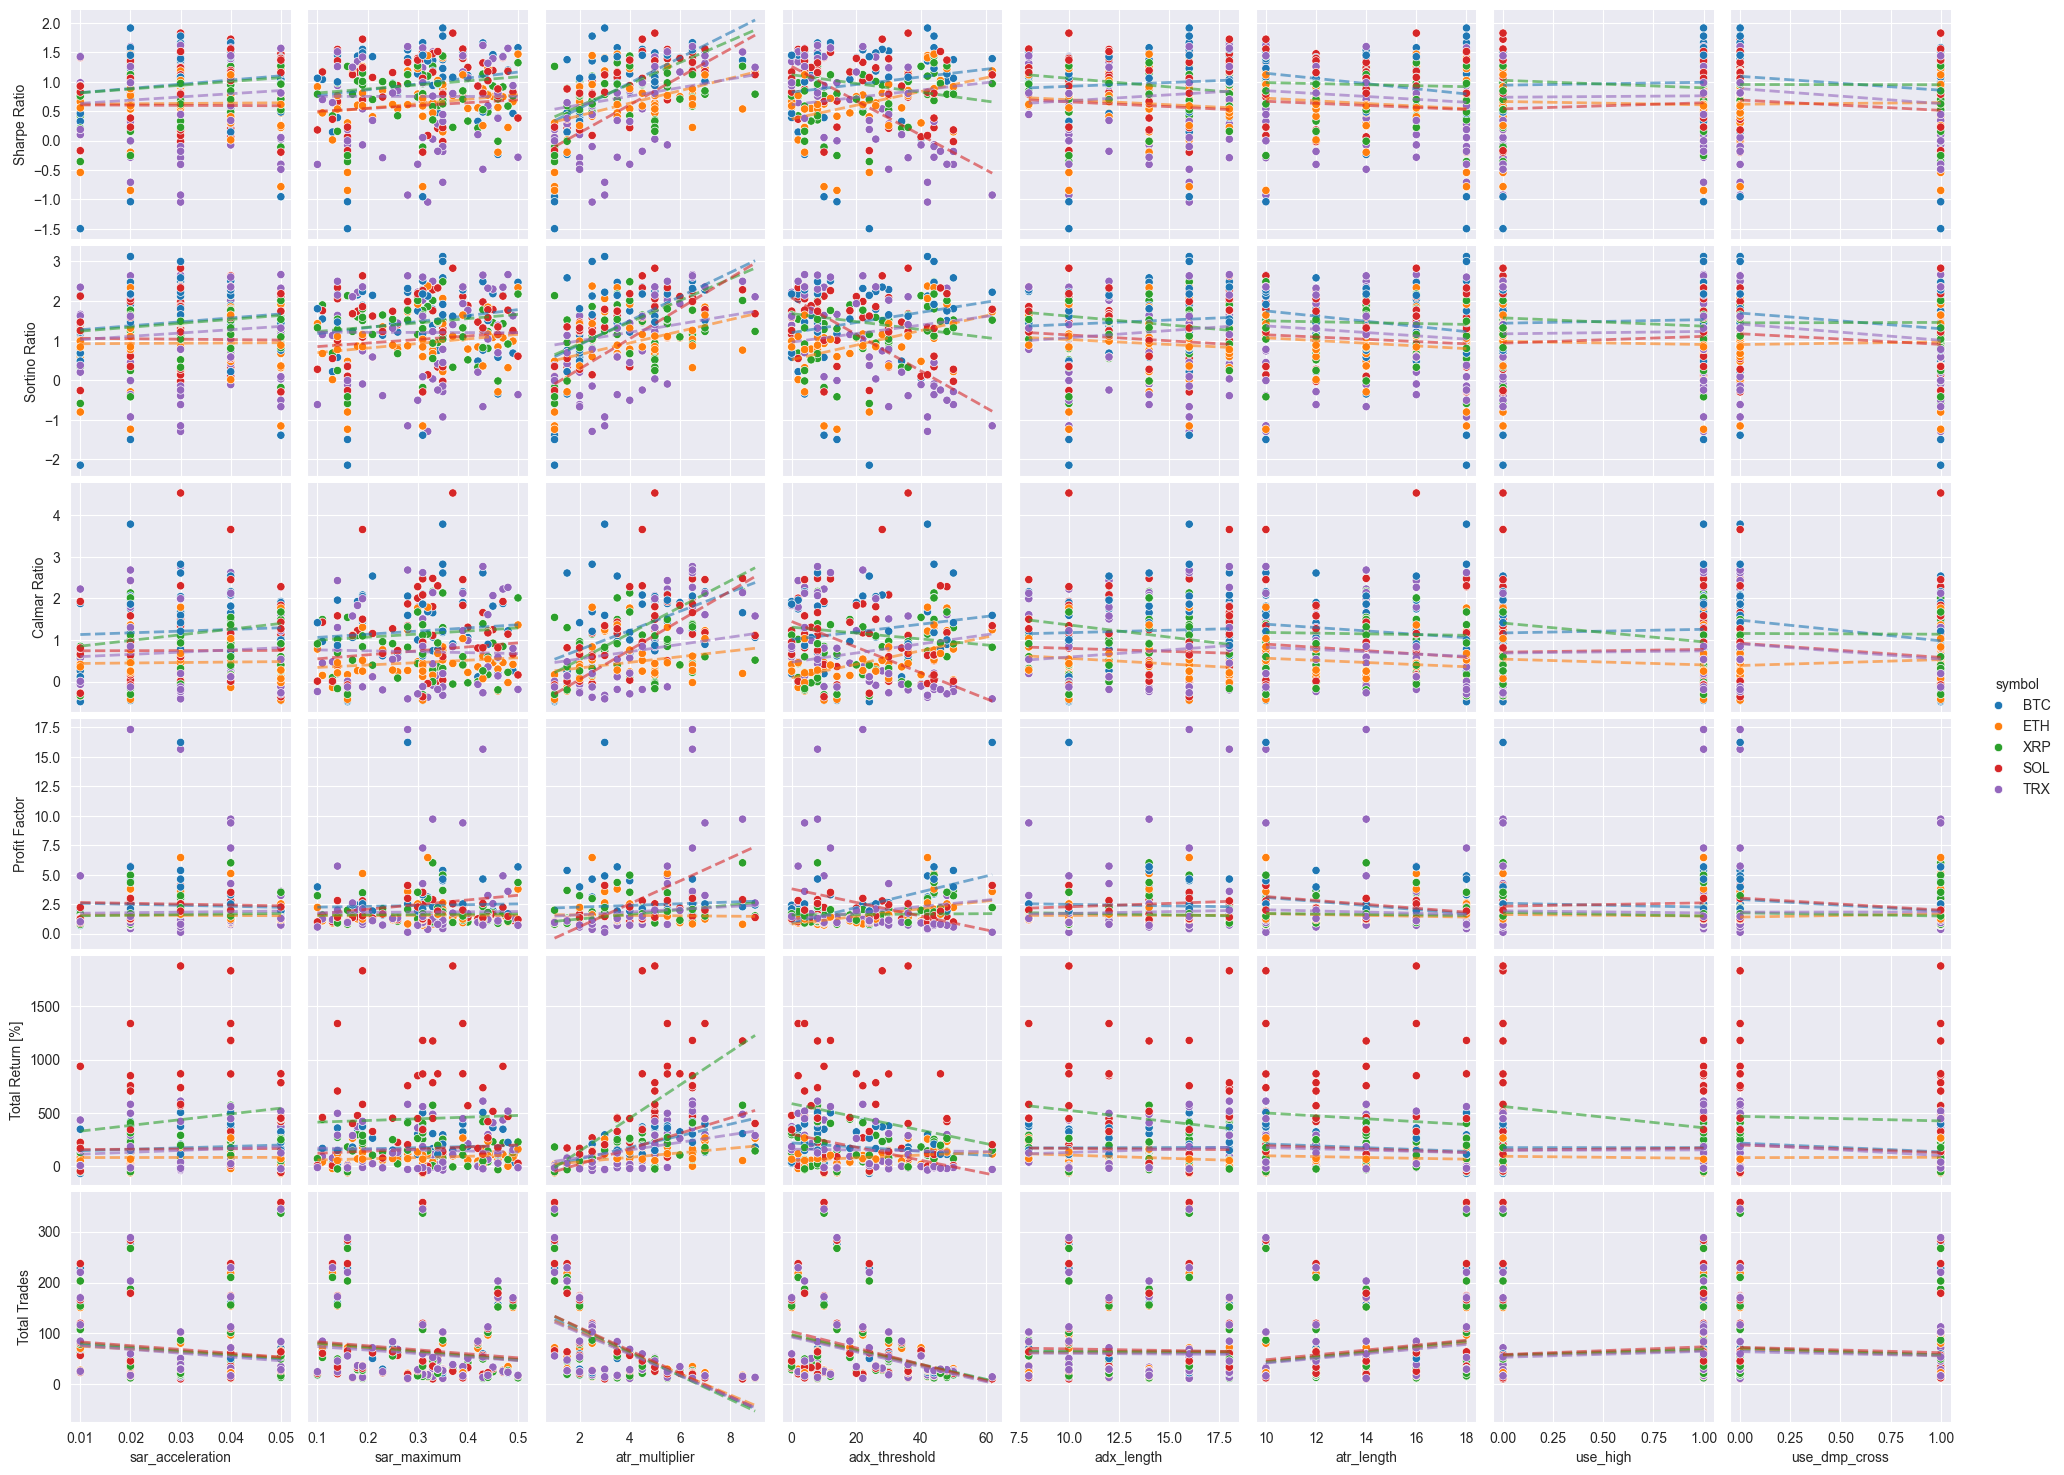

In [132]:

g = sns.pairplot(
    trials_summary,
    x_vars=parameters,
    y_vars=performance,
    hue="symbol",

)
for i, y in enumerate(performance):
    for j, x in enumerate(parameters):
        ax = g.axes[i, j]
        for sym, subdf in trials_summary.groupby("symbol"):
            sns.regplot(
                data=subdf,
                x=x,
                y=y,
                scatter=False,
                ci=None,
                ax=ax,
                label=sym,
                line_kws={
                    "linestyle": "--",  # dashed line
                    "alpha": 0.6,  # transparency
                    "lw": 2,  # line width
                },
            )




## Part2: Further exploration


Update defaults for:
- adx_threshold = 20 --> (8 -- 40)
- adx_length = 10 --> default 14 looks okay
- atr_length = 10 --> default 14 looks okay
- atr_multiplier = 3 --> (4 -- 6.5)
- sar_acceleration = 0.02 --> 0.03
- sar_maximum = 0.2 --> 0.3
- use_dmp_cross = True  --> False

In [133]:
def objective(trial: optuna.Trial):
    # Entry
    params['adx_threshold'] = trial.suggest_int("adx_threshold", 8, 40, step=2)  #
    # params['adx_length'] = trial.suggest_int("adx_length", 2, 50, step=2)
    # params['sar_acceleration'] = trial.suggest_float("sar_acceleration", 0.08, 1.5, step=0.01)
    # params['sar_maximum'] = trial.suggest_float("sar_maximum", 0.07, 1.7, step=0.01)

    # Exit
    params['atr_multiplier'] = trial.suggest_float("atr_multiplier", 4, 6.5, step=0.5)
    # params['atr_length'] = trial.suggest_int("atr_length", 2, 50, step=2)
    # params['use_high'] = trial.suggest_categorical("use_high", [True, False])

    entries, exits, sl_stop = calc_signals(close, high, low, **params)

    pf = vbt.Portfolio.from_signals(close,
                                    entries=entries,
                                    exits=exits,
                                    size=1,
                                    size_type='percent',
                                    direction='longonly',
                                    sl_stop=sl_stop,
                                    sl_trail=True,
                                    freq=interval,
                                    fees=transaction_fee,
                                    init_cash=start_equity,
                                    )
    stats_df = pd.DataFrame({col: pf[col].stats() for col in pf.wrapper.columns})
    sharpe = stats_df.loc["Sharpe Ratio"].mean()

    low_trades = stats_df.loc["Total Trades"].min() < min_trades
    if sharpe is None or math.isnan(sharpe) or math.isinf(sharpe):
        raise optuna.exceptions.TrialPruned("Invalid objective (NaN/Inf).")
    elif low_trades:
        raise optuna.exceptions.TrialPruned("Invalid objective (low trades).")

    wide = stats_df_to_wide(stats_df, trial.number)
    params_df = pd.DataFrame(params, index=wide.index)
    trial_summary = pd.concat([wide, params_df], axis=1)
    trials_summary_list.append(trial_summary)

    return sharpe


trials_summary_list = []
# reset params
params = params_default.copy()
study2 = optuna.create_study(direction="maximize", sampler=sampler)
study2.optimize(objective, n_trials=n_trials)
trials_summary2 = pd.concat(trials_summary_list, axis=0).reset_index(drop=True)

[I 2025-11-10 11:54:28,359] A new study created in memory with name: no-name-b28d8161-447d-4cd0-900a-158ddba6aeb4
[I 2025-11-10 11:54:28,986] Trial 0 finished with value: 1.0894932903298127 and parameters: {'adx_threshold': 16, 'atr_multiplier': 4.5}. Best is trial 0 with value: 1.0894932903298127.
[I 2025-11-10 11:54:29,593] Trial 1 finished with value: 0.9077982697397339 and parameters: {'adx_threshold': 38, 'atr_multiplier': 4.5}. Best is trial 0 with value: 1.0894932903298127.
[I 2025-11-10 11:54:30,179] Trial 2 finished with value: 1.317450971327185 and parameters: {'adx_threshold': 16, 'atr_multiplier': 6.0}. Best is trial 2 with value: 1.317450971327185.
[I 2025-11-10 11:54:30,760] Trial 3 finished with value: 1.2736043073129424 and parameters: {'adx_threshold': 22, 'atr_multiplier': 6.0}. Best is trial 2 with value: 1.317450971327185.
[I 2025-11-10 11:54:31,845] Trial 4 finished with value: 1.1243472669956107 and parameters: {'adx_threshold': 10, 'atr_multiplier': 5.0}. Best is

In [134]:
best_params2 = study2.best_params
best_value2 = study2.best_value
print(f"\nBest --> Sharpe: {best_value2:.2f} ")
print(tabulate(best_params2.items(), tablefmt="github"))


Best --> Sharpe: 1.32 
|----------------|----|
| adx_threshold  | 16 |
| atr_multiplier |  6 |


In [135]:
print(f"\nTop 10% Trials Summary:")
parameters = list(best_params2.keys())
cols = parameters + performance
top_10_pct = int(n_trials * 0.1)
top_runs = trials_summary2.sort_values('Sharpe Ratio', ascending=False).groupby('symbol').head(top_10_pct)
print(f"\nPer symbol:")
print(top_runs.groupby('symbol')[cols].describe())
print(f"\nAcross all symbols:")
print(top_runs[cols].describe())


Top 10% Trials Summary:

Per symbol:
       adx_threshold                                                \
               count  mean       std   min   25%   50%   75%   max   
symbol                                                               
BTC             20.0  29.3  6.061961  14.0  28.0  31.0  32.5  36.0   
ETH             20.0  37.8  1.823819  34.0  36.0  38.0  40.0  40.0   
SOL             20.0  16.7  7.056912   8.0  13.5  16.0  18.0  36.0   
TRX             20.0  15.6  5.752803   8.0  10.0  15.0  22.0  24.0   
XRP             20.0  22.7  6.027132  12.0  18.0  24.0  28.0  30.0   

       atr_multiplier         ... Total Return [%]              Total Trades  \
                count   mean  ...              75%          max        count   
symbol                        ...                                              
BTC              20.0  6.100  ...       521.350908   575.365854         20.0   
ETH              20.0  4.975  ...       216.781574   232.124918         20.0   
S

In [136]:
fig3 = optuna.visualization.plot_param_importances(study2)
show(fig3)

# fig4 = optuna.visualization.plot_slice(study2, params=best_params2.keys())
# show(fig4)


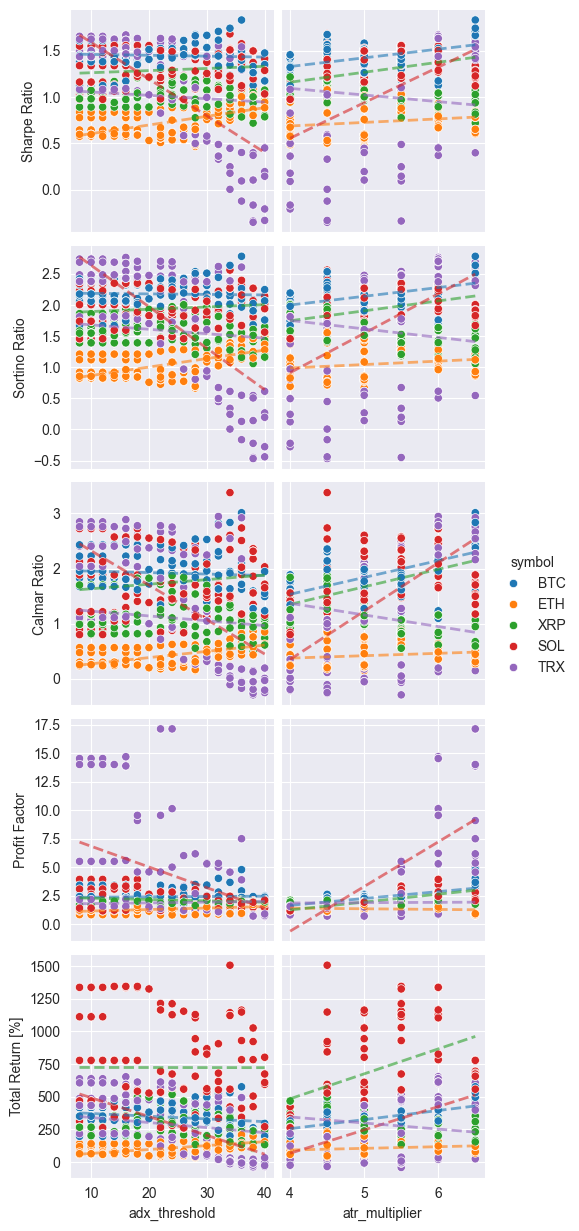

In [137]:
parameters = list(best_params2.keys())
performance = ['Sharpe Ratio', 'Sortino Ratio', 'Calmar Ratio', 'Profit Factor', 'Total Return [%]']
g2 = sns.pairplot(
    trials_summary2,
    x_vars=parameters,
    y_vars=performance,
    hue="symbol",

)
for i, y in enumerate(performance):
    for j, x in enumerate(parameters):
        ax = g2.axes[i, j]
        for sym, subdf in trials_summary2.groupby("symbol"):
            sns.regplot(
                data=subdf,
                x=x,
                y=y,
                scatter=False,
                ci=None,
                ax=ax,
                label=sym,
                line_kws={
                    "linestyle": "--",  # dashed line
                    "alpha": 0.6,  # transparency
                    "lw": 2,  # line width
                },
            )




### All Symbols

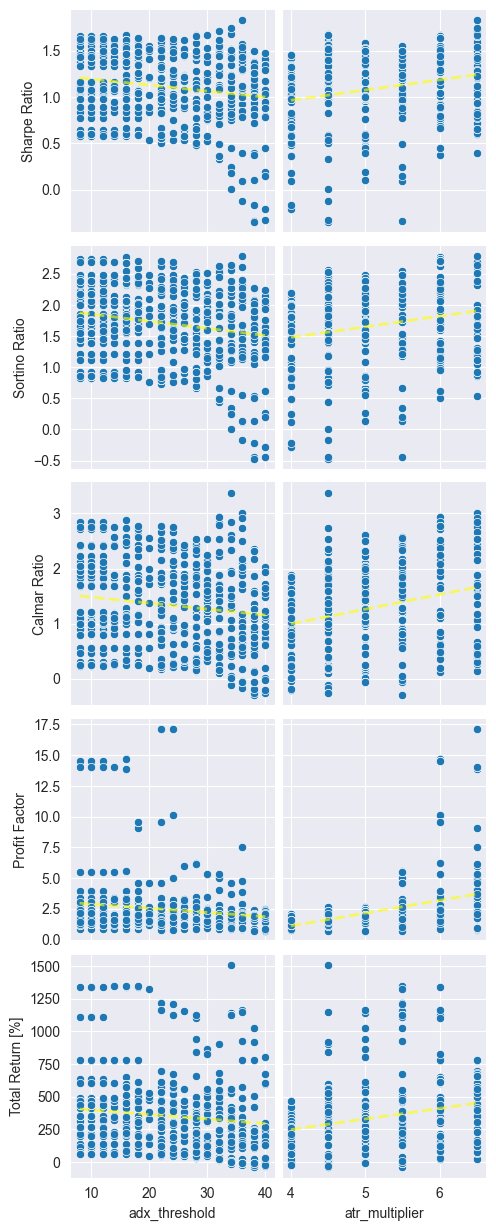

In [138]:
g3 = sns.pairplot(
    trials_summary2,
    x_vars=parameters,
    y_vars=performance,

)
for i, y in enumerate(performance):
    for j, x in enumerate(parameters):
        ax = g3.axes[i, j]
        sns.regplot(
            data=trials_summary2,
            x=x,
            y=y,
            scatter=False,
            ci=None,
            ax=ax,

            line_kws={
                "linestyle": "--",  # dashed line
                "alpha": 0.6,  # transparency
                "lw": 2,  # line width
                "color": "yellow",
            },
        )


## Part 3: Final Results

In [139]:
def objective(trial: optuna.Trial):
    # Entry
    params['adx_threshold'] = trial.suggest_int("adx_threshold", 25, 45, step=1)  #
    # params['adx_length'] = trial.suggest_int("adx_length", 10, 25, step=1)
    # params['sar_acceleration'] = trial.suggest_float("sar_acceleration", 0.08, 1.5, step=0.01)
    # params['sar_maximum'] = trial.suggest_float("sar_maximum", 0.07, 1.7, step=0.01)

    # Exit
    params['atr_multiplier'] = trial.suggest_float("atr_multiplier", 3, 8, step=0.5)
    # params['atr_length'] = trial.suggest_int("atr_length", 14, 40, step=1)
    # params['use_high'] = trial.suggest_categorical("use_high", [True, False])

    entries, exits, sl_stop = calc_signals(close, high, low, **params)

    pf = vbt.Portfolio.from_signals(close,
                                    entries=entries,
                                    exits=exits,
                                    size=1,
                                    size_type='percent',
                                    direction='longonly',
                                    sl_stop=sl_stop,
                                    sl_trail=True,
                                    freq=interval,
                                    fees=transaction_fee,
                                    init_cash=start_equity,
                                    )
    stats_df = pd.DataFrame({col: pf[col].stats() for col in pf.wrapper.columns})
    sharpe = stats_df.loc["Sharpe Ratio"].mean()

    low_trades = stats_df.loc["Total Trades"].min() < min_trades
    if sharpe is None or math.isnan(sharpe) or math.isinf(sharpe):
        raise optuna.exceptions.TrialPruned("Invalid objective (NaN/Inf).")
    elif low_trades:
        raise optuna.exceptions.TrialPruned("Invalid objective (low trades).")

    wide = stats_df_to_wide(stats_df, trial.number)
    params_df = pd.DataFrame(params, index=wide.index)
    trial_summary = pd.concat([wide, params_df], axis=1)
    trials_summary_list.append(trial_summary)

    return sharpe


trials_summary_list = []
# reset params
params = params_default.copy()
study3 = optuna.create_study(direction="maximize", sampler=sampler)
study3.optimize(objective, n_trials=n_trials)
trials_summary3 = pd.concat(trials_summary_list, axis=0).reset_index(drop=True)

[I 2025-11-10 11:56:47,267] A new study created in memory with name: no-name-9a6f87e8-c9fd-432d-a2c1-80df2d1f7f06
[I 2025-11-10 11:56:47,936] Trial 0 finished with value: 0.6945361629612292 and parameters: {'adx_threshold': 32, 'atr_multiplier': 3.0}. Best is trial 0 with value: 0.6945361629612292.
[I 2025-11-10 11:56:48,578] Trial 1 finished with value: 1.0085601654518914 and parameters: {'adx_threshold': 33, 'atr_multiplier': 4.5}. Best is trial 1 with value: 1.0085601654518914.
[I 2025-11-10 11:56:49,234] Trial 2 finished with value: 0.8734517540240324 and parameters: {'adx_threshold': 39, 'atr_multiplier': 6.0}. Best is trial 1 with value: 1.0085601654518914.
[I 2025-11-10 11:56:49,848] Trial 3 finished with value: 0.9191606895215323 and parameters: {'adx_threshold': 32, 'atr_multiplier': 4.0}. Best is trial 1 with value: 1.0085601654518914.
[I 2025-11-10 11:56:50,489] Trial 4 finished with value: 0.9994513634856641 and parameters: {'adx_threshold': 45, 'atr_multiplier': 5.0}. Best

In [140]:
best_params3 = study3.best_params
best_value3 = study3.best_value
print(f"\nBest --> Sharpe: {best_value3:.2f} ")
print(tabulate(best_params3.items(), tablefmt="github"))


Best --> Sharpe: 1.37 
|----------------|------|
| adx_threshold  | 31   |
| atr_multiplier |  7.5 |


In [141]:
print(f"\nTop 10% Trials Summary:")
parameters = list(best_params3.keys())
cols = parameters + performance
top_10_pct = int(n_trials * 0.1)
top_runs = trials_summary3.sort_values('Sharpe Ratio', ascending=False).groupby('symbol').head(top_10_pct)
print(f"\nPer symbol:")
print(top_runs.groupby('symbol')[cols].describe())
print(f"\nAcross all symbols:")
print(top_runs[cols].describe())

# nan values?

print(f"\nBot 10% Trials Summary:")
bot_runs = trials_summary3.sort_values('Sharpe Ratio', ascending=True).groupby('symbol').head(top_10_pct)
print(f"\nAcross all symbols:")
print(bot_runs[cols].describe())

# final look

print(trials_summary.info())

# Why are some Profit factor NaN or inf


Top 10% Trials Summary:

Per symbol:
       adx_threshold                                                   \
               count   mean       std   min    25%   50%    75%   max   
symbol                                                                  
BTC             20.0  33.65  6.425893  26.0  27.00  32.5  37.00  44.0   
ETH             20.0  43.45  2.163696  37.0  42.00  45.0  45.00  45.0   
SOL             20.0  37.25  6.758036  25.0  34.00  36.5  43.25  45.0   
TRX             20.0  30.05  4.097175  25.0  26.75  30.0  32.75  37.0   
XRP             20.0  28.80  5.327189  25.0  25.75  26.5  30.25  44.0   

       atr_multiplier         ... Profit Factor            Total Return [%]  \
                count   mean  ...           75%        max            count   
symbol                        ...                                             
BTC              20.0  6.650  ...      4.065642   4.807496             20.0   
ETH              20.0  4.725  ...      3.468710   3.613438   

In [142]:
fig5 = optuna.visualization.plot_param_importances(study3)
show(fig5)


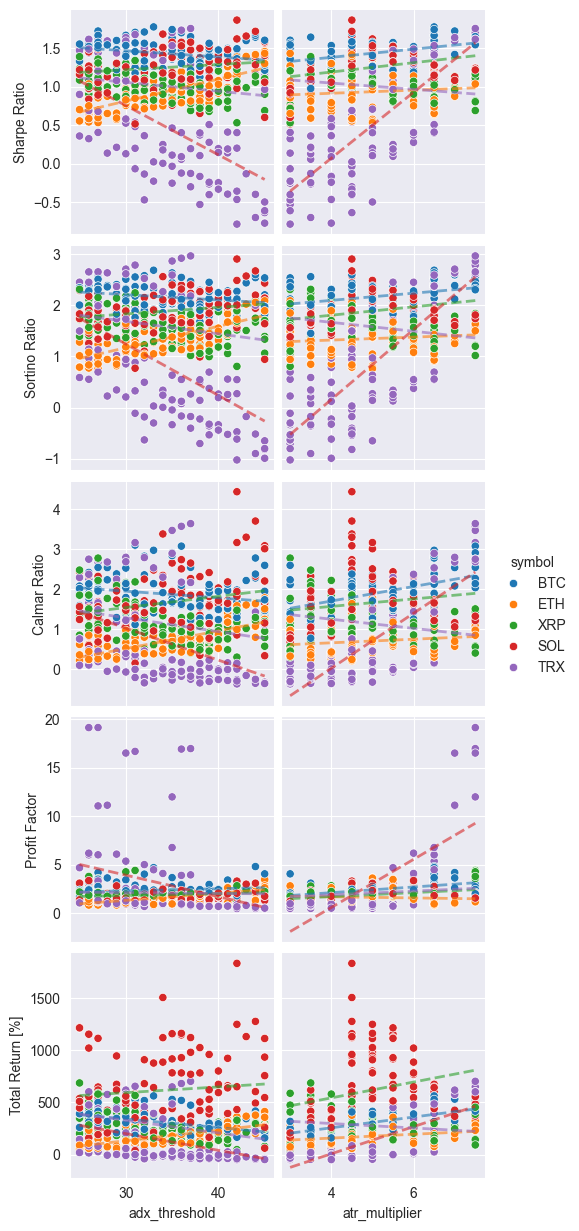

In [143]:
parameters = list(best_params3.keys())
performance = ['Sharpe Ratio', 'Sortino Ratio', 'Calmar Ratio', 'Profit Factor', 'Total Return [%]']
g4 = sns.pairplot(
    trials_summary3,
    x_vars=parameters,
    y_vars=performance,
    hue="symbol",

)
for i, y in enumerate(performance):
    for j, x in enumerate(parameters):
        ax = g4.axes[i, j]
        for sym, subdf in trials_summary3.groupby("symbol"):
            sns.regplot(
                data=subdf,
                x=x,
                y=y,
                scatter=False,
                ci=None,
                ax=ax,
                label=sym,
                line_kws={
                    "linestyle": "--",  # dashed line
                    "alpha": 0.6,  # transparency
                    "lw": 2,  # line width
                },
            )




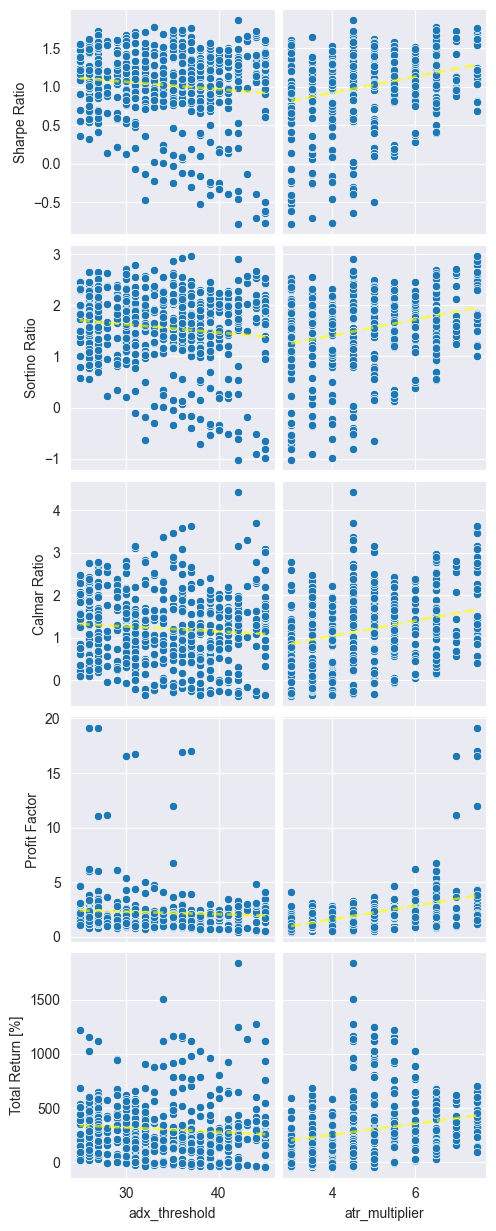

In [144]:
g5 = sns.pairplot(
    trials_summary3,
    x_vars=parameters,
    y_vars=performance,

)
for i, y in enumerate(performance):
    for j, x in enumerate(parameters):
        ax = g5.axes[i, j]
        sns.regplot(
            data=trials_summary3,
            x=x,
            y=y,
            scatter=False,
            ci=None,
            ax=ax,

            line_kws={
                "linestyle": "--",  # dashed line
                "alpha": 0.6,  # transparency
                "lw": 2,  # line width
                "color": "yellow",
            },
        )


### Final Parameter Search Space

In [145]:
params_default = {'sar_acceleration': 0.02,  # little correlation
                  'sar_maximum': 0.2,  # has little correlation
                  'adx_threshold': [25, 45],  # higher adx_thresholds can result in no trades being executed
                  'adx_length': [14, 25],  # for entry
                  'atr_multiplier': [2, 6],  # for exit
                  'atr_length': [14, 25],  # atr multiplier for  exit
                  'use_high': False,
                  }




## Part 4: Extra, hmm but what does Optuna think is best?

I'll use the default search space and let Optuna explore the space and find the best parameters.

In [146]:
def objective(trial: optuna.Trial):
    # Entry
    params['adx_threshold'] = trial.suggest_int("adx_threshold", 10, 46, step=2)  #
    params['adx_length'] = trial.suggest_int("adx_length", 10, max_lookback, step=2)
    # params['sar_acceleration'] = trial.suggest_float("sar_acceleration", 0.02, 1.5, step=0.01)
    # params['sar_maximum'] = trial.suggest_float("sar_maximum", 0.05, 1.7, step=0.01)

    # Exit
    params['atr_multiplier'] = trial.suggest_float("atr_multiplier", 1, 10, step=0.5)
    params['atr_length'] = trial.suggest_int("atr_length", 10, max_lookback, step=2)
    # params['use_high'] = trial.suggest_categorical("use_high", [True, False])

    entries, exits, sl_stop = calc_signals(close, high, low, **params)

    pf = vbt.Portfolio.from_signals(close,
                                    entries=entries,
                                    exits=exits,
                                    size=1,
                                    size_type='percent',
                                    direction='longonly',
                                    sl_stop=sl_stop,
                                    sl_trail=True,
                                    freq=interval,
                                    fees=transaction_fee,
                                    init_cash=start_equity,
                                    )
    stats_df = pd.DataFrame({col: pf[col].stats() for col in pf.wrapper.columns})
    sharpe = stats_df.loc["Sharpe Ratio"].mean()

    low_trades = stats_df.loc["Total Trades"].min() < min_trades
    if sharpe is None or math.isnan(sharpe) or math.isinf(sharpe):
        raise optuna.exceptions.TrialPruned("Invalid objective (NaN/Inf).")
    elif low_trades:
        raise optuna.exceptions.TrialPruned("Invalid objective (low trades).")
    wide = stats_df_to_wide(stats_df, trial.number)
    params_df = pd.DataFrame(params, index=wide.index)
    trial_summary = pd.concat([wide, params_df], axis=1)
    trials_summary_list.append(trial_summary)

    return sharpe


trials_summary_list = []
params = params_default.copy()
study_opt = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
study_opt.optimize(objective, n_trials=n_trials)
trials_summary_opt = pd.concat(trials_summary_list, axis=0).reset_index(drop=True)

[I 2025-11-10 11:59:12,949] A new study created in memory with name: no-name-26196796-def2-4b57-9b8d-65cb08d31c96
[I 2025-11-10 11:59:14,134] Trial 0 finished with value: 1.0170963440273675 and parameters: {'adx_threshold': 24, 'adx_length': 18, 'atr_multiplier': 6.0, 'atr_length': 14}. Best is trial 0 with value: 1.0170963440273675.
[I 2025-11-10 11:59:14,789] Trial 1 finished with value: -0.44684374323992665 and parameters: {'adx_threshold': 14, 'adx_length': 10, 'atr_multiplier': 1.0, 'atr_length': 18}. Best is trial 0 with value: 1.0170963440273675.
[I 2025-11-10 11:59:15,403] Trial 2 finished with value: 0.1388448465352555 and parameters: {'adx_threshold': 32, 'adx_length': 16, 'atr_multiplier': 1.0, 'atr_length': 18}. Best is trial 0 with value: 1.0170963440273675.
[I 2025-11-10 11:59:16,008] Trial 3 finished with value: 0.43861236513319407 and parameters: {'adx_threshold': 40, 'adx_length': 12, 'atr_multiplier': 2.0, 'atr_length': 10}. Best is trial 0 with value: 1.0170963440273

In [147]:
trials = study_opt.trials_dataframe()
trials.sort_values('value', inplace=True, ascending=False)
trials.columns = trials.columns.str.removeprefix('params_')
trials.drop(['datetime_start', 'datetime_complete', 'duration', 'state'], axis=1, inplace=True)
print(tabulate(trials, headers='keys', tablefmt='github', showindex=False))



|   number |       value |   adx_length |   adx_threshold |   atr_length |   atr_multiplier |
|----------|-------------|--------------|-----------------|--------------|------------------|
|      108 |   1.2977    |           12 |              34 |           10 |              7.5 |
|       67 |   1.28836   |           12 |              10 |           10 |              8   |
|       66 |   1.28836   |           12 |              10 |           10 |              8   |
|       65 |   1.28836   |           12 |              10 |           10 |              8   |
|       69 |   1.28836   |           12 |              10 |           10 |              8   |
|       68 |   1.28836   |           12 |              10 |           10 |              8   |
|      136 |   1.28836   |           12 |              10 |           10 |              8   |
|      138 |   1.28836   |           12 |              10 |           10 |              8   |
|      140 |   1.28836   |           12 |              10 | 

In [148]:
parameters = list(params.keys())
performance = ['Sharpe Ratio', 'Sortino Ratio', 'Calmar Ratio', 'Profit Factor', 'Total Return [%]']

print(f"\nTop 10% Trials Summary:")
cols = parameters + performance
top_10_pct = int(n_trials * 0.1)
top_runs = trials_summary_opt.sort_values('Sharpe Ratio', ascending=False).groupby('symbol').head(top_10_pct)
print(f"\nPer symbol:")
print(top_runs.groupby('symbol')[cols].describe())
print(f"\nAcross all symbols:")
print(top_runs[cols].describe())

best_params = study.best_params
best_value = study.best_value
print(f"\nBest --> Sharpe: {best_value:.2f} ")
print(tabulate(best_params.items(), tablefmt="github"))


Top 10% Trials Summary:

Per symbol:
       sar_acceleration                                                    \
                  count  mean           std   min   25%   50%   75%   max   
symbol                                                                      
BTC                20.0  0.02  3.559577e-18  0.02  0.02  0.02  0.02  0.02   
ETH                20.0  0.02  3.559577e-18  0.02  0.02  0.02  0.02  0.02   
SOL                20.0  0.02  3.559577e-18  0.02  0.02  0.02  0.02  0.02   
TRX                20.0  0.02  3.559577e-18  0.02  0.02  0.02  0.02  0.02   
XRP                20.0  0.02  3.559577e-18  0.02  0.02  0.02  0.02  0.02   

       sar_maximum       ... Profit Factor            Total Return [%]  \
             count mean  ...           75%        max            count   
symbol                   ...                                             
BTC           20.0  0.2  ...      3.032760   3.588874             20.0   
ETH           20.0  0.2  ...      1.796878   4.25

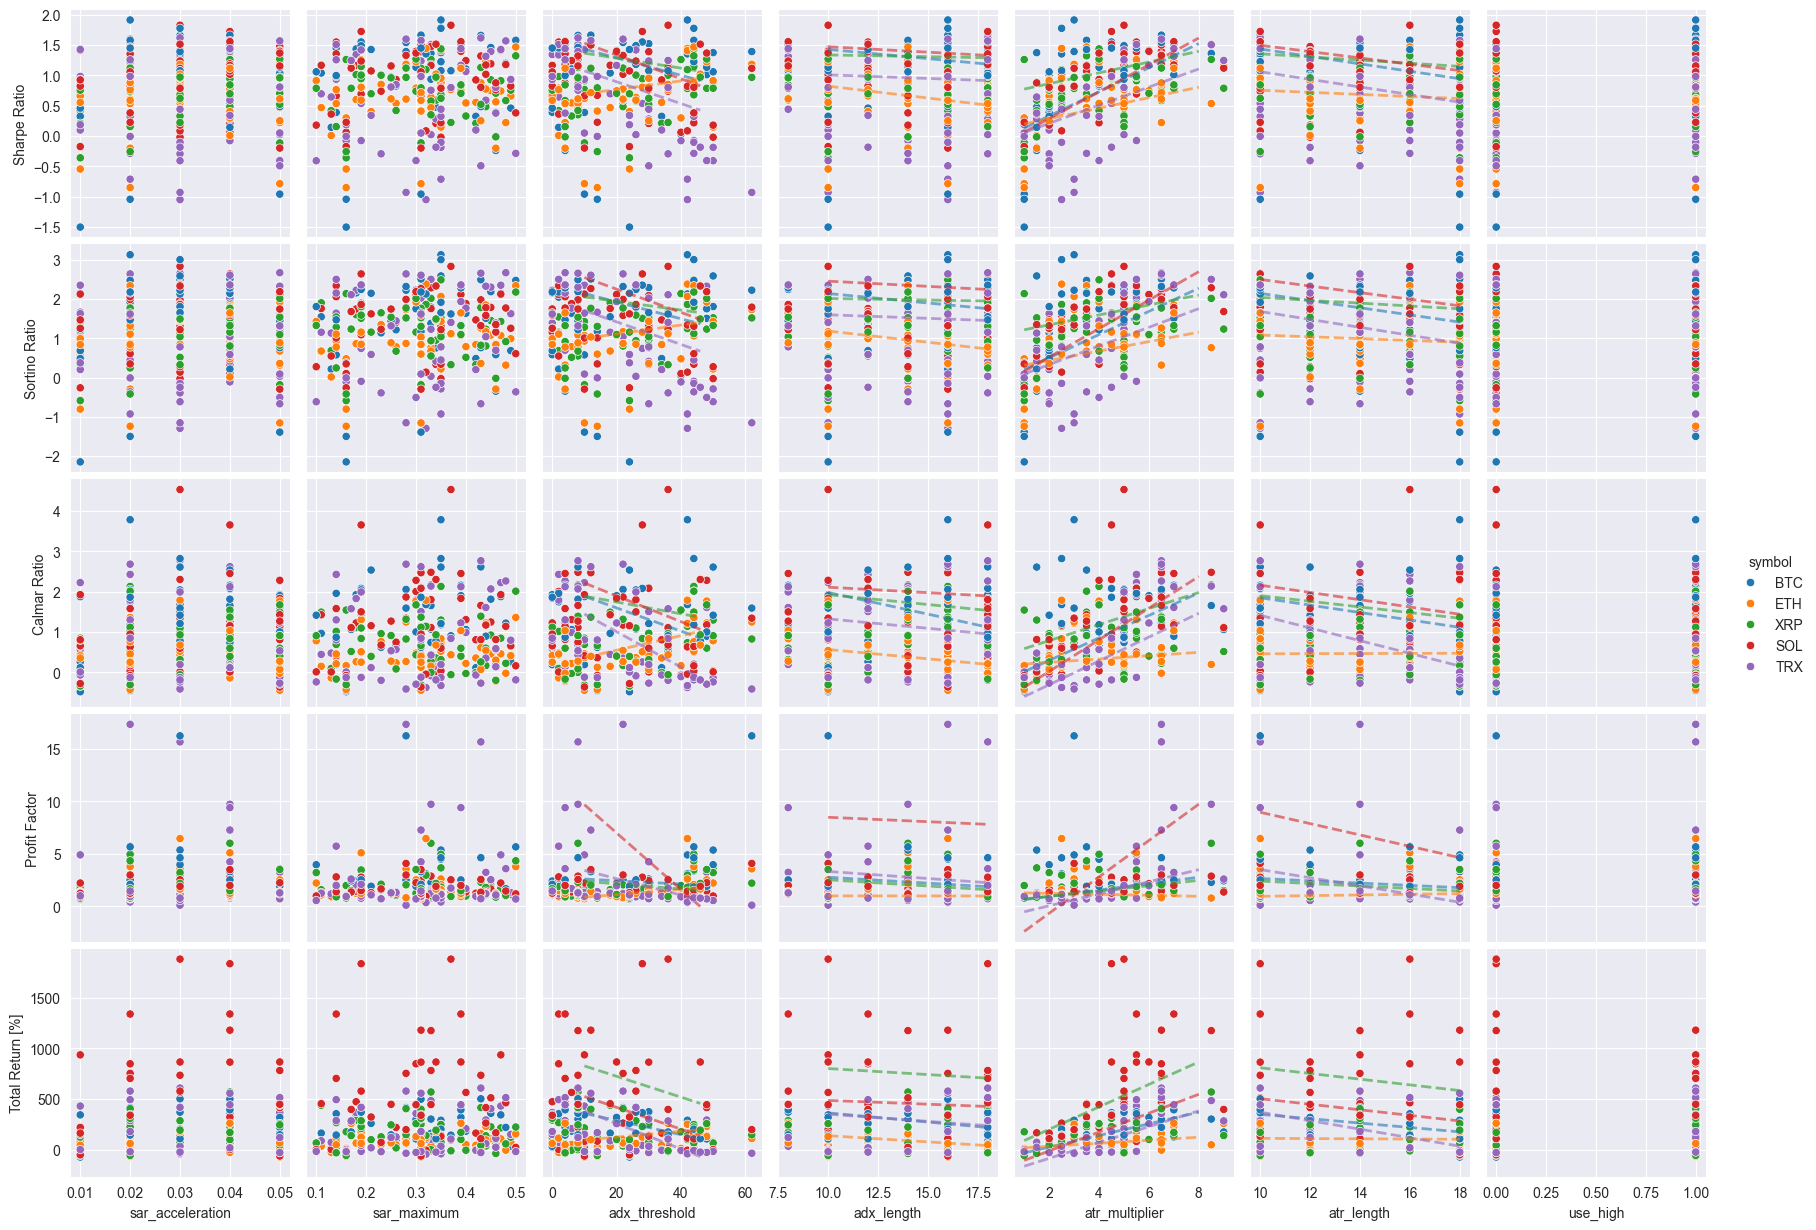

In [149]:
fig_opt = optuna.visualization.plot_param_importances(study_opt)
show(fig_opt)
fig_opt1 = optuna.visualization.plot_optimization_history(study_opt)
show(fig_opt1)
fig_opt2 = optuna.visualization.plot_slice(study_opt)
show(fig_opt2)

g_opt = sns.pairplot(
    trials_summary,
    x_vars=parameters,
    y_vars=performance,
    hue="symbol",

)
for i, y in enumerate(performance):
    for j, x in enumerate(parameters):
        ax = g_opt.axes[i, j]
        for sym, subdf in trials_summary_opt.groupby("symbol"):
            sns.regplot(
                data=subdf,
                x=x,
                y=y,
                scatter=False,
                ci=None,
                ax=ax,
                label=sym,
                line_kws={
                    "linestyle": "--",  # dashed line
                    "alpha": 0.6,  # transparency
                    "lw": 2,  # line width
                },
            )


